In [1]:
import scomv
import stlearn as st
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import pandas as pd
import numpy as np
import anndata
import scanpy as sc
import seaborn as sns
from adjustText import adjust_text
from scipy.cluster.hierarchy import linkage, dendrogram, ClusterNode, to_tree

/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/nomura/miniconda3/envs/sc-test310/lib/python3.10/site-packages/stlearn/tl/cci/het.py:206: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit(parallel=True, nopython=False)


In [2]:
#!mkdir tutorial_data
#!mkdir tutorial_data/xenium_data
#!wget -P tutorial_data/xenium_data/ https://cf.10xgenomics.com/samples/xenium/preview/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_cell_feature_matrix.h5
#!wget -P tutorial_data/xenium_data/ https://cf.10xgenomics.com/samples/xenium/preview/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_cells.csv.gz

In [3]:
# Load Xenium data using stlearn
adata = st.ReadXenium(
    feature_cell_matrix_file="../tutorial_data/xenium_data/cell_feature_matrix.h5",
    cell_summary_file="../tutorial_data/xenium_data/cells.csv.gz",
    library_id="example data",
    image_path=None,
    scale=1,
    spot_diameter_fullres=10
)

In [4]:
#sc.pp.filter_cells(adata, min_genes=100) 
sc.pp.filter_genes(adata, min_cells=30)
print(adata)

AnnData object with n_obs × n_vars = 167780 × 313
    obs: 'imagecol', 'imagerow'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'


In [5]:
# Gridding at 10μm interval using stlearn
N_COL = int((adata.obs.imagecol.max() - adata.obs.imagecol.min()) / 10)
N_ROW = int((adata.obs.imagerow.max() - adata.obs.imagerow.min()) / 10)
grid = st.tl.cci.grid(adata, n_row=N_ROW, n_col=N_COL, n_cpus=10, verbose=False)

In [6]:
from scomv.preparation.skny_calc_distance import calculate_distance

In [7]:
## apply SKNY
grid = calculate_distance(
    grid, pos_marker_ls=['CDH1',"EPCAM"],
)

[calculate_distance] N_ROW=547, N_COL=752, positive cells in grid=100012/411344


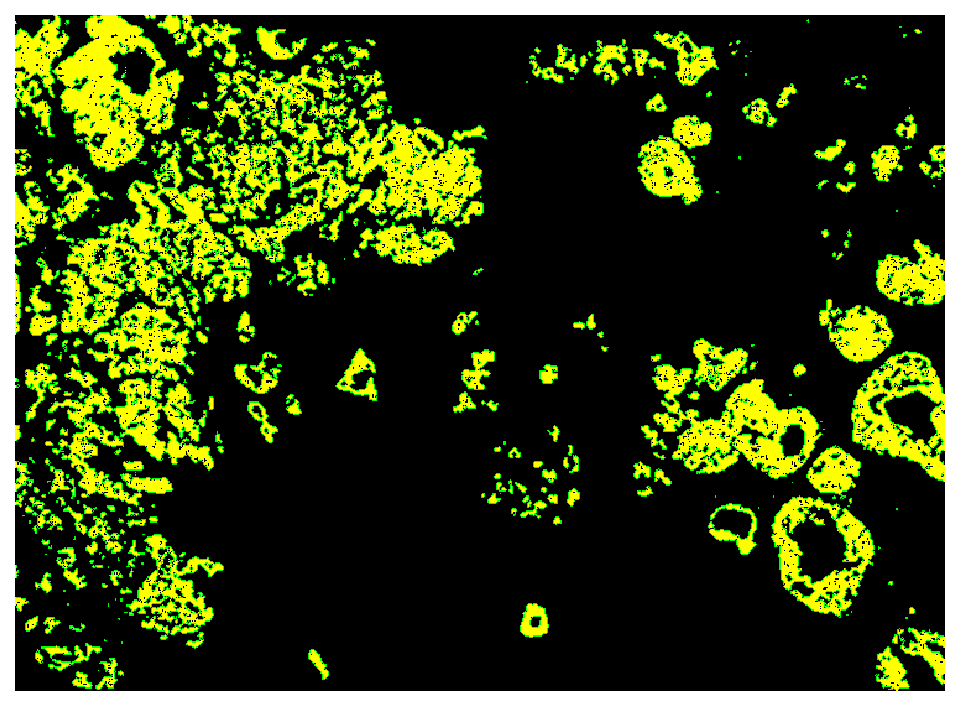

In [8]:
# Figure 2B
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.imshow(cv2.cvtColor(grid.uns["marker_median_delineation"], cv2.COLOR_BGR2RGB),
          interpolation="nearest")
ax.axis("off")
plt.show()

#plt.savefig("Figure_2B.png", dpi=300)

In [13]:
import plotly.express as px
import plotly.io as pio
import cv2
import numpy as np

# Convert BGR (OpenCV) image to RGB for Plotly display
img = cv2.cvtColor(grid.uns["marker_median_delineation"], cv2.COLOR_BGR2RGB)

scale = 10  # spatial scaling factor

fig = px.imshow(img)

h, w = img.shape[:2]

# ---- Scale axis tick labels by a factor of 10 ----
step = 200
fig.update_xaxes(
    tickmode="array",
    tickvals=list(range(0, w, step)),
    ticktext=[str(v * scale) for v in range(0, w, step)]
)
fig.update_yaxes(
    tickmode="array",
    tickvals=list(range(0, h, step)),
    ticktext=[str(v * scale) for v in range(0, h, step)]
)

# ---- Create a full-resolution coordinate grid for hover display ----
# xx: scaled x-coordinates for each pixel (shape: h × w)
# yy: scaled y-coordinates for each pixel (shape: h × w)
xx = (np.arange(w)[None, :] * scale).repeat(h, axis=0)
yy = (np.arange(h)[:, None] * scale).repeat(w, axis=1)

# Stack into (h, w, 2) so hover can access scaled x and y
custom = np.dstack([xx, yy])

# ---- Override hover text to show scaled spatial coordinates ----
fig.update_traces(
    customdata=custom,
    hovertemplate="x: %{customdata[0]}<br>y: %{customdata[1]}<extra></extra>"
)

fig.update_layout(
    title="Figure 2B",
    xaxis_title="x",
    yaxis_title="y",
    height=700
)

# Use the notebook-connected renderer for interactive display
pio.renderers.default = "notebook_connected"

fig.show()

# ↓↓ Zooming and cropping are supported interactively ↓↓

In [10]:
# annotation each section to obs object
df_shotest = getattr(grid, "shortest")
df_grid = grid.to_df()

# extract grid info
df_grid = pd.merge(
    pd.DataFrame(index=["grid_" + str(i+1) for i in range(N_ROW * N_COL)]),
    df_grid, right_index=True, left_index=True, how="left"
).fillna(np.nan)

# extract section info
df_region = pd.DataFrame(
    np.array(df_shotest["region"]).reshape(N_ROW, N_COL).T.reshape(N_ROW * N_COL),
    index=["grid_" + str(i+1) for i in range(N_ROW * N_COL)], columns=["region"]
)

# marge
df_grid_region = pd.merge(
    df_grid, df_region,
    right_index=True, left_index=True, how="left"
)
df_grid_region = df_grid_region.dropna()

# add to obs
grid.obs = pd.merge(
    grid.obs, df_grid_region[["region"]],
    right_index=True, left_index=True, how="left"
)

# shaping
grid.obs["region_10"] = [str(i*10) for i in grid.obs["region"]]
grid.obs["region_10"] = ["("+str(int(float(i.split(", ")[0][1:])))+", "+str(int(float(i.split(", ")[-1][:-1])))+"]" if i != "nan" else np.nan for i in grid.obs["region_10"]]
# exclude because of small number
grid.obs["region_10"] = grid.obs["region_10"].replace(
    {"(-150, -120]": np.nan}
)

In [22]:
# import
import plotly.express as px
from plotly.subplots import make_subplots
import cv2


def equidistant_curves(
    grid, figsize=(None, None)
):

    data = grid.uns["shotest_30_delineation"]
    
    fig = make_subplots()
    fig.add_trace(
        px.imshow(
            cv2.cvtColor(data, cv2.COLOR_BGR2RGB)
        ).data[0]
    )
    fig.update_layout(height=figsize[0], width=figsize[1],
                      dragmode='pan', 
                      title_text="Equidistant curves")
    
    fig.show(config = {
        'scrollZoom': True,
        'toImageButtonOptions': {
            'format': 'png', # one of png, svg, jpeg, webp
            'filename': 'preprocessed_images',
            'height': figsize[0],
            'width': figsize[1],
            'scale': 2 } # Multiply title/legend/axis/canvas sizes by this factor
    })
    

In [24]:
grid.uns.keys()

odict_keys(['spatial', 'grid_counts', 'grid_xedges', 'grid_yedges', 'marker', 'marker_median', 'marker_delineation', 'shotest', 'marker_median_delineation', 'shotest_30_delineation', 'shotest_region_(-12, -9]_delineation', 'shotest_region_(-9, -6]_delineation', 'shotest_region_(-6, -3]_delineation', 'shotest_region_(-3, 0]_delineation', 'shotest_region_(0, 3]_delineation', 'shotest_region_(3, 6]_delineation', 'shotest_region_(6, 9]_delineation', 'shotest_region_(9, 12]_delineation', 'shotest_region_(12, 15]_delineation', 'shotest_region_(15, 18]_delineation', 'shotest_region_(18, 21]_delineation', 'shotest_region_(21, 24]_delineation', 'shotest_region_(24, 27]_delineation', 'shotest_region_(27, 30]_delineation'])

In [27]:
equidistant_curves(grid, figsize=(500, None))

In [64]:
from scomv.preparation.choose_roi import extract_roi, contour_regions

In [65]:
# select ROI
roi = (2400, 3400, 2400, 3800)

subset_grid, filtered_shortest, xy_list = extract_roi(
    grid=grid,
    roi=roi,
    bin_size=10,
    region_col="region_10",
)

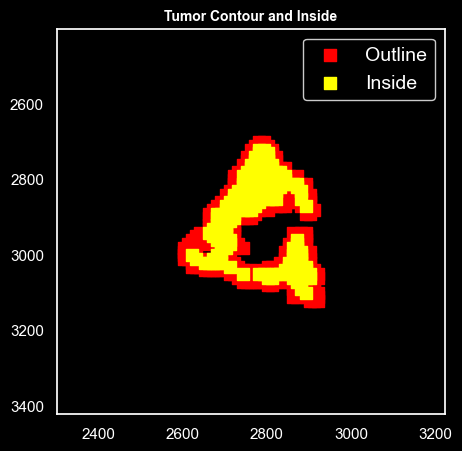

In [66]:
g_x_cont, g_y_cont, g_x_inside, g_y_inside = contour_regions(
    filtered_shortest, adata,
    min_x=0, max_x=4000, min_y=0, max_y=4000,
    #out_dir_base="./roi_plots",
    show=True,
)

In [67]:
from scomv.preparation.scomv_calc_vector import compute_min_vectors_polar

In [68]:
outline_points = list(zip(g_x_cont, g_y_cont))
inside_points  = list(zip(g_x_inside, g_y_inside))

min_vector_df = compute_min_vectors_polar(
    xy_list=xy_list,
    outline_points=outline_points,
    inside_points=inside_points,
    invert_y=True,
    make_inside_negative=True,
)

In [69]:
from scomv.gene_view_tool import plot_gene_polar_hist2d, plot_2d_expression

CD3E: n=3431


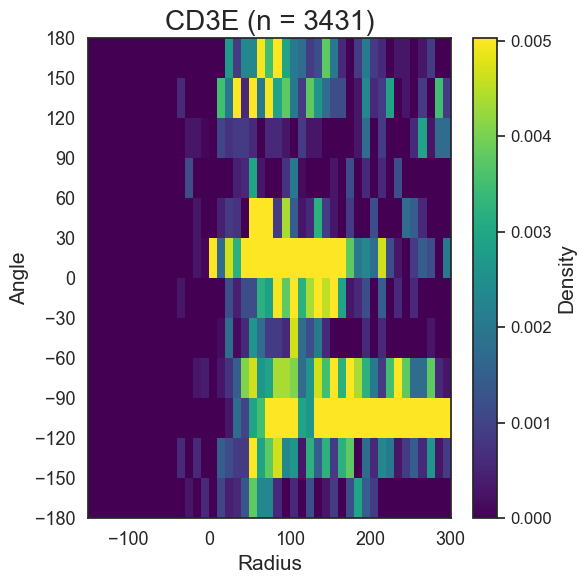

In [70]:
## Draw polar maps
genes = list(subset_grid.var.index)
A_counts, total_n, idx = plot_gene_polar_hist2d(
    subset_grid=subset_grid,
    min_vector_df=min_vector_df,
    gene="CD3E",
)


GJB2: n=1784


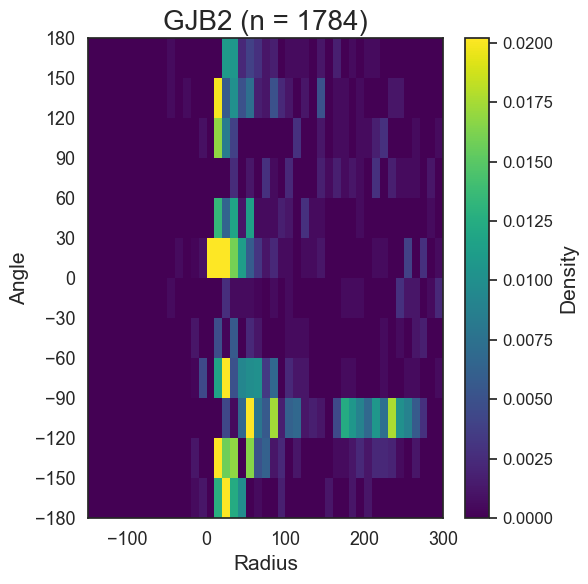

In [71]:
from scomv.polar_slice_viewer import plot_polar_slice_interactive

A_counts, _, _ = plot_gene_polar_hist2d(
    subset_grid=subset_grid,
    min_vector_df=min_vector_df,
    gene="GJB2",
)

In [72]:
plot_polar_slice_interactive(A_counts, gene_name="GJB2")

Please specify a valid `library_id` or set it permanently in `adata.uns['spatial']`


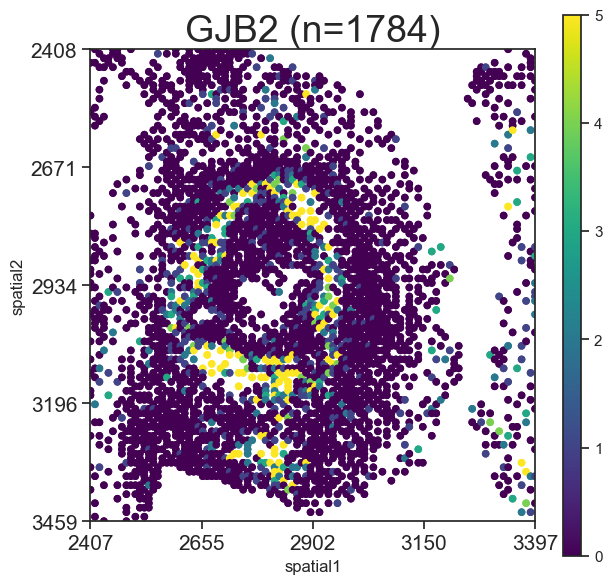

In [73]:
## Draw 2D pictures
gs = ["GJB2"] # the genes you want to draw
for g in gs:
    plot_2d_expression(g, subset_grid)

In [74]:
from scomv.gene_pipeline import SCOMVPipeline

gene_pipe = SCOMVPipeline(adata=adata, grid=grid, bin_size=10)
gene_out = gene_pipe.run(roi=(2400, 3400, 2400, 3800))

In [75]:
import plotly.io as pio
gene_pipe.plot_pcoa_plotly(gene_pipe.coords, gene_pipe.selected_genes)

In [76]:
from scomv.peripheral_score import (
    rank_genes_by_peripheral_score,
    plot_angle_profile,
)

# Rank all genes by peripheral score (d = 0-50 μm outside boundary)
# Columns:
#   peripheral_score : coverage * uniformity  (high = uniform near boundary)
#   coverage         : fraction of expression within [d_lo, d_hi]
#   uniformity       : normalized Shannon entropy (0=concentrated, 1=uniform)
#   rho1             : 1st circular moment (high = unimodal bias)
#   rho2             : 2nd circular moment (high = bimodal; adjacent vs opposite via rho1)
score_df = rank_genes_by_peripheral_score(
    gene_pipe.polar_counts_list,
    gene_pipe.selected_genes,
    d_lo=10, d_hi=50,
)
score_df.head(30)

,gene,peripheral_score,coverage,uniformity,rho1,rho2
0,GJB2,0.395153,0.449371,0.879347,0.061149,0.240973
1,SNAI1,0.365295,0.439252,0.831630,0.046552,0.427125
2,SSTR2,0.280770,0.397849,0.705718,0.311402,0.150480
3,ACTA2,0.269068,0.313266,0.858914,0.157815,0.083868
4,APOBEC3A,0.236883,0.285714,0.829089,0.165112,0.290593
5,MMP12,0.226133,0.362069,0.624558,0.656565,0.415133
6,CEACAM8,0.216720,0.239583,0.904571,0.193046,0.078382
7,C5orf46,0.212849,0.251825,0.845227,0.175962,0.124554
8,AHSP,0.209207,0.500000,0.418414,0.183013,0.500000
9,SVIL,0.208891,0.228356,0.914764,0.114357,0.072815


In [77]:
score_df["partial_peripheral_score"] = score_df["coverage"] * score_df["rho1"]                                        
score_df.sort_values("partial_peripheral_score", ascending=False).head(20)

,gene,peripheral_score,coverage,uniformity,rho1,rho2,partial_peripheral_score
5,MMP12,0.226133,0.362069,0.624558,0.656565,0.415133,0.237722
42,CCL8,0.162144,0.234127,0.692547,0.684072,0.207757,0.160160
267,MYBPC1,0.037617,0.138889,0.270840,0.967312,0.871780,0.134349
226,SCGB2A1,0.064371,0.153846,0.418414,0.846467,0.500000,0.130226
188,CCL20,0.083336,0.179487,0.464300,0.695936,0.654654,0.124912
2,SSTR2,0.280770,0.397849,0.705718,0.311402,0.150480,0.123891
18,S100A8,0.193839,0.260417,0.744341,0.459625,0.307896,0.119694
10,KRT23,0.208128,0.270419,0.769648,0.433895,0.376161,0.117334
159,LIF,0.101288,0.179688,0.563688,0.574219,0.501416,0.103180
142,CYP1A1,0.111689,0.208333,0.536108,0.478834,0.529150,0.099757


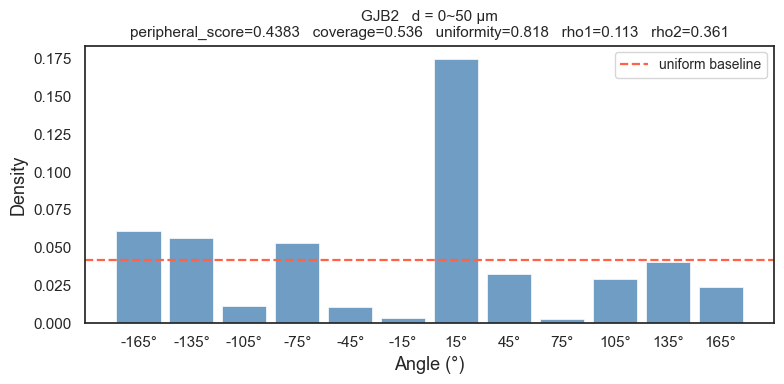

In [78]:
# Angle profile for a gene of interest
# Flat bars == high uniformity (entropy) == peripheral
# One peak  == high rho1  -> unimodal (partially peripheral)
# Two opposite peaks == high rho2 + low rho1 -> bimodal
# Two adjacent peaks == high rho1 + high rho2 -> local cluster
target_gene = score_df['gene'].iloc[0]  # top-ranked gene
gene_idx = gene_pipe.selected_genes.index(target_gene)
plot_angle_profile(
    gene_pipe.polar_counts_list[gene_idx],
    gene_name=target_gene,
    d_lo=0, d_hi=50,
)

In [79]:
# ── Top-30 peripheral score genes: polar slice viewer + 2D spatial ────────
_g2c = dict(zip(gene_pipe.selected_genes, gene_pipe.polar_counts_list))

for _gene in score_df.head(30)["gene"]:
    _row = score_df.loc[score_df["gene"] == _gene].iloc[0]
    print(
        f"▶ {_gene}  "
        f"(peripheral_score={_row['peripheral_score']:.4f}, "
        f"coverage={_row['coverage']:.3f}, "
        f"uniformity={_row['uniformity']:.3f})"
    )
    plot_polar_slice_interactive(
        A_counts=_g2c[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ GJB2  (peripheral_score=0.3952, coverage=0.449, uniformity=0.879)


▶ SNAI1  (peripheral_score=0.3653, coverage=0.439, uniformity=0.832)


▶ SSTR2  (peripheral_score=0.2808, coverage=0.398, uniformity=0.706)


▶ ACTA2  (peripheral_score=0.2691, coverage=0.313, uniformity=0.859)


▶ APOBEC3A  (peripheral_score=0.2369, coverage=0.286, uniformity=0.829)


...

▶ FSTL3  (peripheral_score=0.1803, coverage=0.208, uniformity=0.868)


▶ SQLE  (peripheral_score=0.1797, coverage=0.194, uniformity=0.927)


▶ CEACAM6  (peripheral_score=0.1794, coverage=0.201, uniformity=0.892)


▶ PCLAF  (peripheral_score=0.1794, coverage=0.209, uniformity=0.857)


▶ SCD  (peripheral_score=0.1785, coverage=0.197, uniformity=0.906)


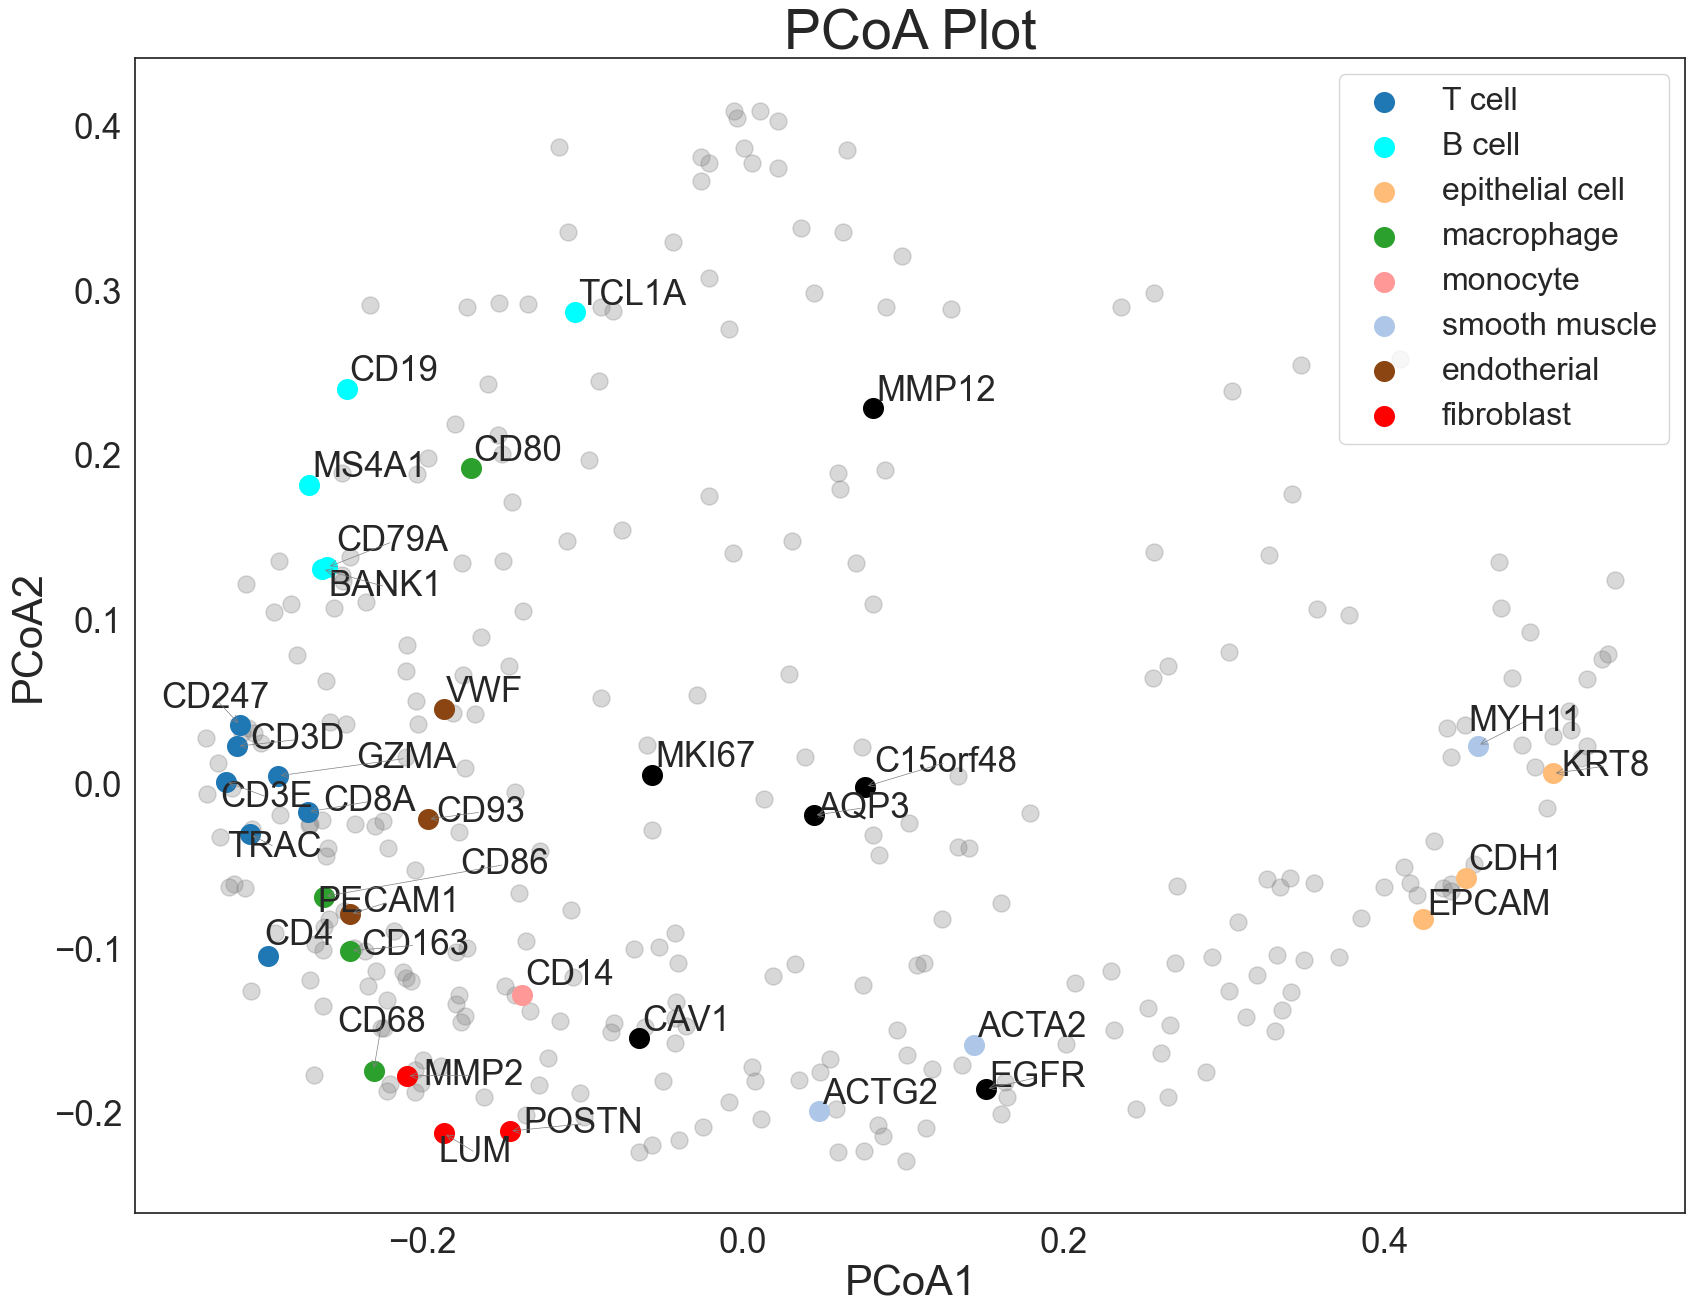

In [80]:
pcoa_two_dims = gene_out["coords"][["PC1", "PC2"]]
df = pcoa_two_dims

# --- Gene sets ---
t_cells  = {"CD3D", "CD3E", "CD4", "CD247", "CD8A", "GZMA", "TRAC"}
micro_f  = ["CD68", "CD80", "CD86", "CD163"]
b_cells  = ["CD19", "BANK1", "MS4A1", "TCL1A", "CD79A"]
mono     = ["CD14"]
epi      = ["CDH1", "EPCAM", "KRT8"]
smooth   = ["ACTA2", "MYH11", "ACTG2"]
endo     = ["CD93", "PECAM1", "VWF"]
fib      = ["POSTN", "LUM", "MMP2"]
focus    = ["PLVAP", "RHOA", "SMAD6", "TP53", "VEGFA", "MKI67", "ADGRL4", "RGS5",
            "PI3", "CAV1", "EGFR", "AQP3", "C15orf48", "MMP12"]

# --- Others (everything except T-cell set) ---
others = sorted(list(set(df.index) - set(t_cells)))

# --- Styling config (keeps your colors/labels/sizes) ---
groups = [
    ("T cell",          t_cells,  "#1f77b4", 200, True),
    ("B cell",          b_cells,  "cyan",    200, True),
    ("epithelial cell", epi,      "#ffbb78", 200, True),
    ("macrophage",      micro_f,  "#2ca02c", 200, True),
    ("monocyte",        mono,     "#ff9896", 200, True),
    ("smooth muscle",   smooth,   "#aec7e8", 200, True),
    ("endotherial",     endo,     "#8B4513", 200, True), 
    ("fibroblast",      fib,      "red",     200, True),
    (None,              focus,    "black",   200, True),  # no legend label
]

# --- Plot ---
plt.figure(figsize=(20, 15))
sns.set_theme(style="white")
texts = []

# Others: gray points (no labels)
for g in others:
    if g in df.index:
        plt.scatter(df.loc[g, "PC1"], df.loc[g, "PC2"], color="gray", alpha=0.3, s=150)

# Highlighted groups
for label, gene_list, color, s, add_text in groups:
    for g in gene_list:
        if g in df.index:
            if label is None:
                plt.scatter(df.loc[g, "PC1"], df.loc[g, "PC2"], color=color, s=s)
            else:
                plt.scatter(df.loc[g, "PC1"], df.loc[g, "PC2"], color=color, label=label, s=s)
            if add_text:
                texts.append(plt.text(df.loc[g, "PC1"], df.loc[g, "PC2"], g, fontsize=25))

plt.xlabel("PCoA1", fontsize=30)
plt.ylabel("PCoA2", fontsize=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.title("PCoA Plot", fontsize=40)

# Legend (remove duplicates)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="best", prop={"size": 23}, ncol=1)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color="gray", lw=0.5),
    only_move={"points": "xy", "text": "xy"},
    force_text=1.5,
    force_points=1.0,
    expand_text=(1.2, 1.2),
    expand_points=(1.2, 1.2),
    lim=200,
    precision=0.01,
    autoalign="y",
)

plt.show()

In [81]:
from scomv.plot_3d import plot_3d
import plotly.io as pio

fig = plot_3d(
    adata=gene_out["subset_grid"],
    genes=("POSTN", "CD3E"),
    anchor_gene="CDH1",
    bin_size=10,
    x_range=(2400, 3100),
    y_range=(2400, 3400),
    height_scale=3,
    anchor_scale=1,
    threshold=4,
    sigma=1.0,
)
pio.renderers.default = "notebook_connected"
fig.show()


In [82]:
from scomv.dendrogram import dendrogram2newick
z = linkage(gene_out["dist_df"], metric='euclidean', method='ward')
tree= to_tree(z)
newick = dendrogram2newick(tree, tree.dist, gene_out["selected_genes"])

/var/folders/h5/02yhm93d3kn1__fczqjdr9cw0000gp/T/ipykernel_8466/1097620655.py:2: ClusterWarning:

scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



In [83]:
# The Newick output can be used to visualize a dendrogram in iTOL(https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://itol.embl.de/&ved=2ahUKEwiY7vnzxoOSAxWRrlYBHUuiHisQFnoECBoQAQ&usg=AOvVaw2ipidUpg8SauabV53lQ6Jh).
#newick

In [84]:
# ── Lymphocyte + CAF gene panel ────────────────────────────────────────────
LYMPHOCYTE_PANEL = {
    # ── Lymphocyte lineage ──────────────────────────────────────────────────
    "T cell (general)": ["CD3D", "CD3E", "CD3G", "CD247", "IL7R", "SELL", "PTPRC"],
    "CD4 T cell":       ["CD4", "IL2RA", "FOXP3", "CTLA4", "ICOS", "TIGIT", "IKZF2"],
    "CD8 T cell":       ["CD8A", "CD8B", "GZMA", "GZMB", "GZMK", "PRF1", "IFNG", "NKG7"],
    "NK cell":          ["NCAM1", "KLRD1", "GNLY", "NKG7", "FCGR3A", "KLRB1", "XCL1"],
    "B cell":           ["CD19", "MS4A1", "CD79A", "CD79B", "BANK1", "TCL1A", "PAX5"],
    "Plasma cell":      ["MZB1", "IGHG1", "IGKC", "IGLC2", "JCHAIN", "SDC1"],
    "Treg":             ["FOXP3", "IL2RA", "TIGIT", "IKZF2", "CTLA4"],
    # ── Cancer-Associated Fibroblasts (CAF) ─────────────────────────────────
    "CAF (general)":    ["PDGFRA", "PDGFRB", "FAP", "FN1", "VIM", "S100A4",
                         "POSTN", "LUM", "DCN", "MMP2", "LRRC15"],
    "myCAF":            ["ACTA2", "MYH11", "TAGLN", "ACTG2", "CNN1", "MYLK"],
    "iCAF":             ["IL6", "CXCL12", "CXCL14", "LIF", "HAS2", "CFD", "CXCL1"],
    "apCAF":            ["HLA-DRA", "CD74", "SLPI", "CLDN4", "LTBP2"],
}

# ── Check availability in the current pipeline run ────────────────────────
print(f"Total genes in pipeline: {len(gene_pipe.selected_genes)}\n")
print(f"{'Cell type':<22} {'Available':<40} {'Missing'}")
print("─" * 90)

available_per_group = {}
for cell_type, genes in LYMPHOCYTE_PANEL.items():
    unique_genes = list(dict.fromkeys(genes))
    avail = [g for g in unique_genes if g in gene_pipe.selected_genes]
    miss  = [g for g in unique_genes if g not in gene_pipe.selected_genes]
    available_per_group[cell_type] = avail
    print(f"{cell_type:<22} {str(avail):<40} {miss}")

Total genes in pipeline: 313

Cell type              Available                                Missing
──────────────────────────────────────────────────────────────────────────────────────────
T cell (general)       ['CD3D', 'CD3E', 'CD3G', 'CD247', 'IL7R', 'SELL', 'PTPRC'] []
CD4 T cell             ['CD4', 'IL2RA', 'FOXP3', 'CTLA4', 'TIGIT'] ['ICOS', 'IKZF2']
CD8 T cell             ['CD8A', 'CD8B', 'GZMA', 'GZMB', 'GZMK', 'PRF1', 'NKG7'] ['IFNG']
NK cell                ['NCAM1', 'KLRD1', 'GNLY', 'NKG7', 'FCGR3A', 'KLRB1'] ['XCL1']
B cell                 ['CD19', 'MS4A1', 'CD79A', 'CD79B', 'BANK1', 'TCL1A'] ['PAX5']
Plasma cell            ['MZB1']                                 ['IGHG1', 'IGKC', 'IGLC2', 'JCHAIN', 'SDC1']
Treg                   ['FOXP3', 'IL2RA', 'TIGIT', 'CTLA4']     ['IKZF2']
CAF (general)          ['PDGFRA', 'PDGFRB', 'S100A4', 'POSTN', 'LUM', 'MMP2', 'LRRC15'] ['FAP', 'FN1', 'VIM', 'DCN']
myCAF                  ['ACTA2', 'MYH11', 'ACTG2', 'MYLK']      ['TAGLN', 'C

In [85]:
# ── Peripheral score summary for all available lymphocyte genes ───────────
all_lympho_genes = list(dict.fromkeys(
    g for genes in available_per_group.values() for g in genes
))

# Assign cell-type label (first matching group wins)
gene_to_celltype = {}
for ct, genes in available_per_group.items():
    for g in genes:
        gene_to_celltype.setdefault(g, ct)

lympho_score_df = (
    score_df[score_df["gene"].isin(all_lympho_genes)]
    .copy()
    .assign(cell_type=lambda df: df["gene"].map(gene_to_celltype))
    .sort_values(["cell_type", "peripheral_score"], ascending=[True, False])
    .reset_index(drop=True)
)

print(lympho_score_df[
    ["cell_type", "gene", "peripheral_score", "coverage", "uniformity", "rho1", "rho2"]
].to_string(index=False))

       cell_type   gene  peripheral_score  coverage    uniformity     rho1     rho2
          B cell  BANK1      3.360417e-02  0.045213  7.432451e-01 0.418643 0.212091
          B cell  CD79B      2.921371e-02  0.066667  4.382056e-01 0.754508 0.400000
          B cell   CD19      2.412324e-02  0.055556  4.342184e-01 0.428571 0.142857
          B cell  MS4A1      2.271569e-02  0.040476  5.612111e-01 0.569225 0.636274
          B cell  CD79A      1.468121e-02  0.026316  5.578859e-01 0.591506 0.500000
          B cell  TCL1A     -6.707161e-13  0.016667 -4.024296e-11 1.000000 1.000000
   CAF (general) LRRC15      1.933909e-01  0.215027  8.993786e-01 0.140980 0.147986
   CAF (general) PDGFRB      1.590294e-01  0.179295  8.869727e-01 0.151555 0.183143
   CAF (general) S100A4      1.535988e-01  0.168022  9.141564e-01 0.099746 0.117826
   CAF (general)  POSTN      1.504477e-01  0.167642  8.974321e-01 0.121554 0.132477
   CAF (general)    LUM      1.477849e-01  0.163210  9.054870e-01 0.135083 0

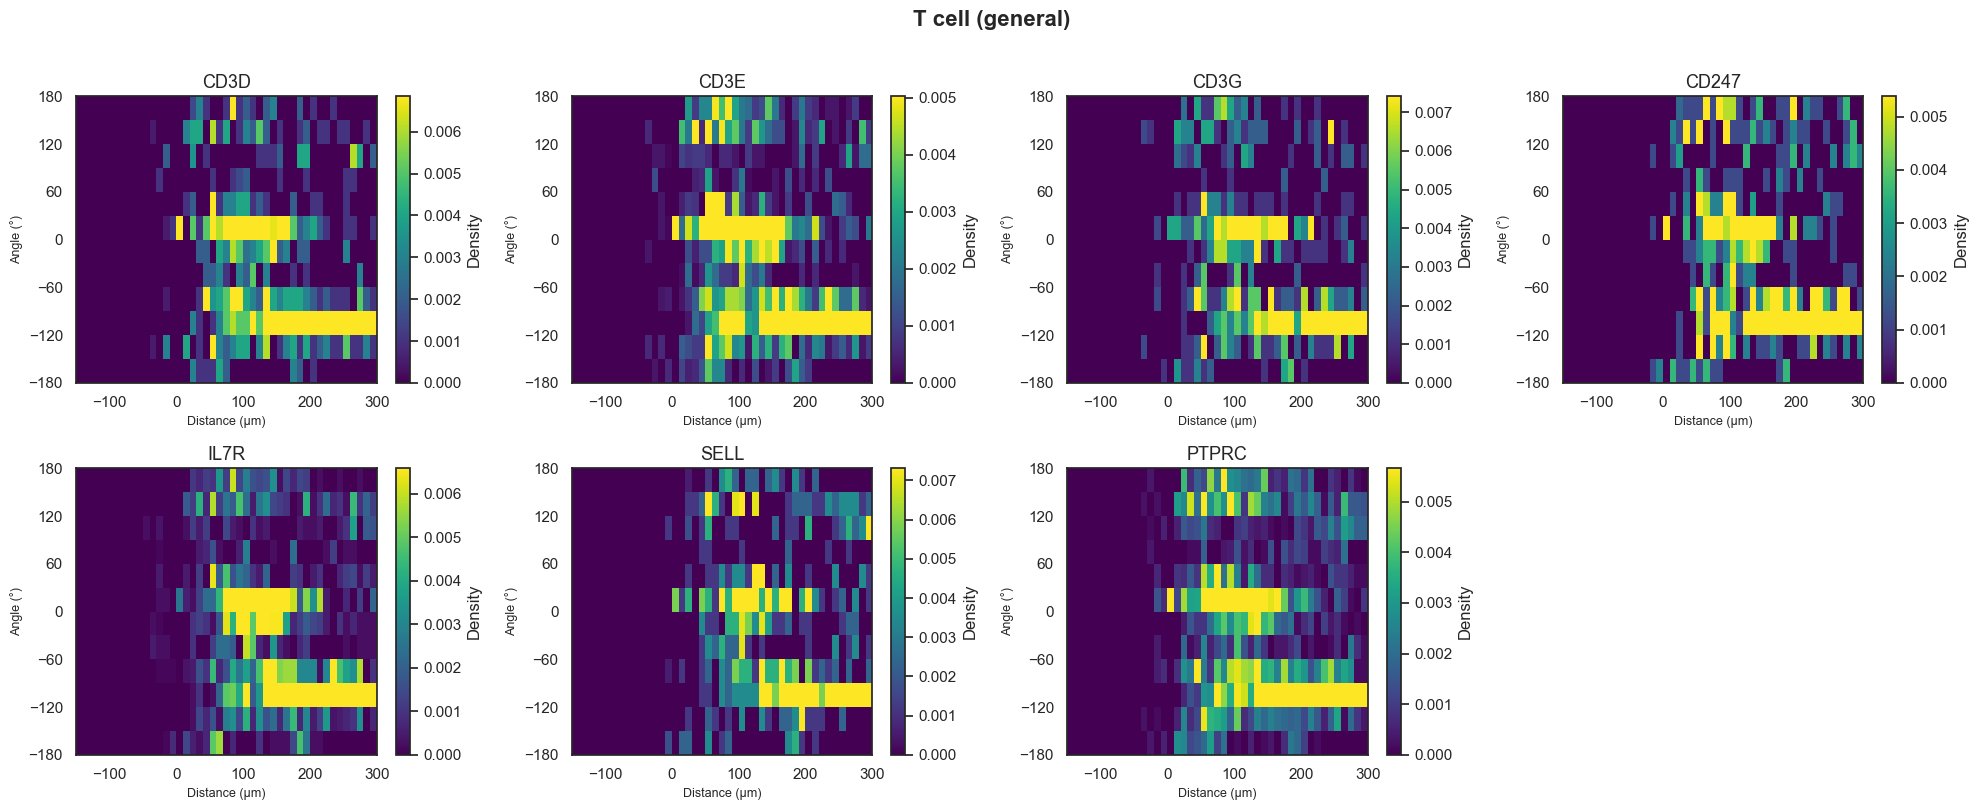

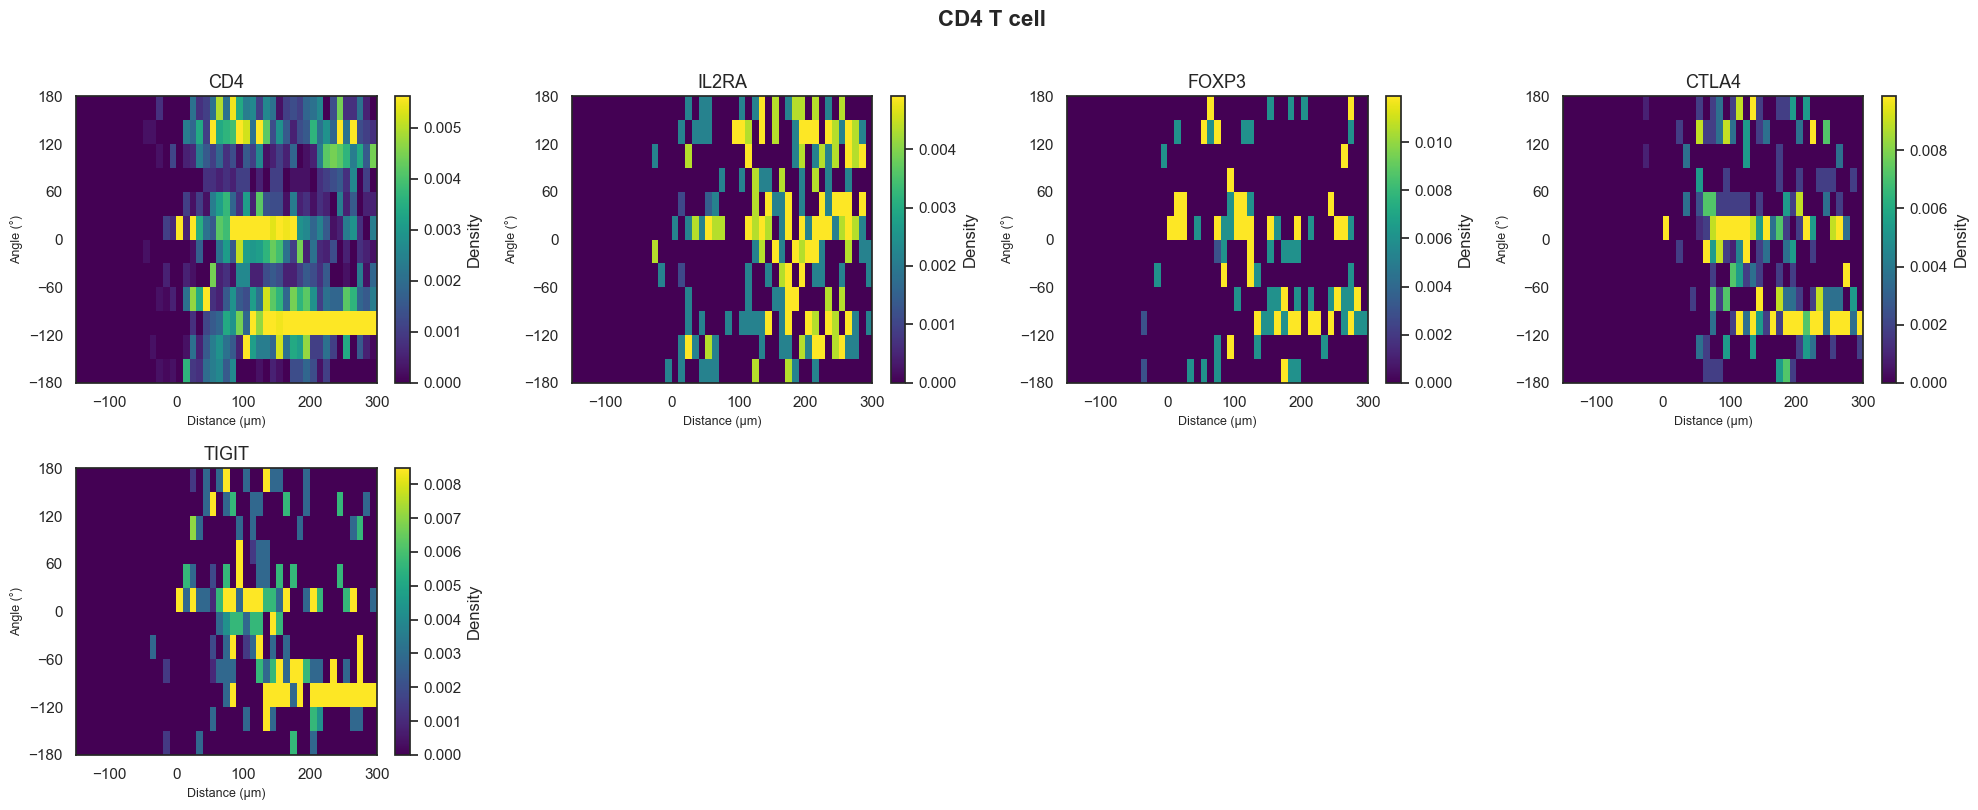

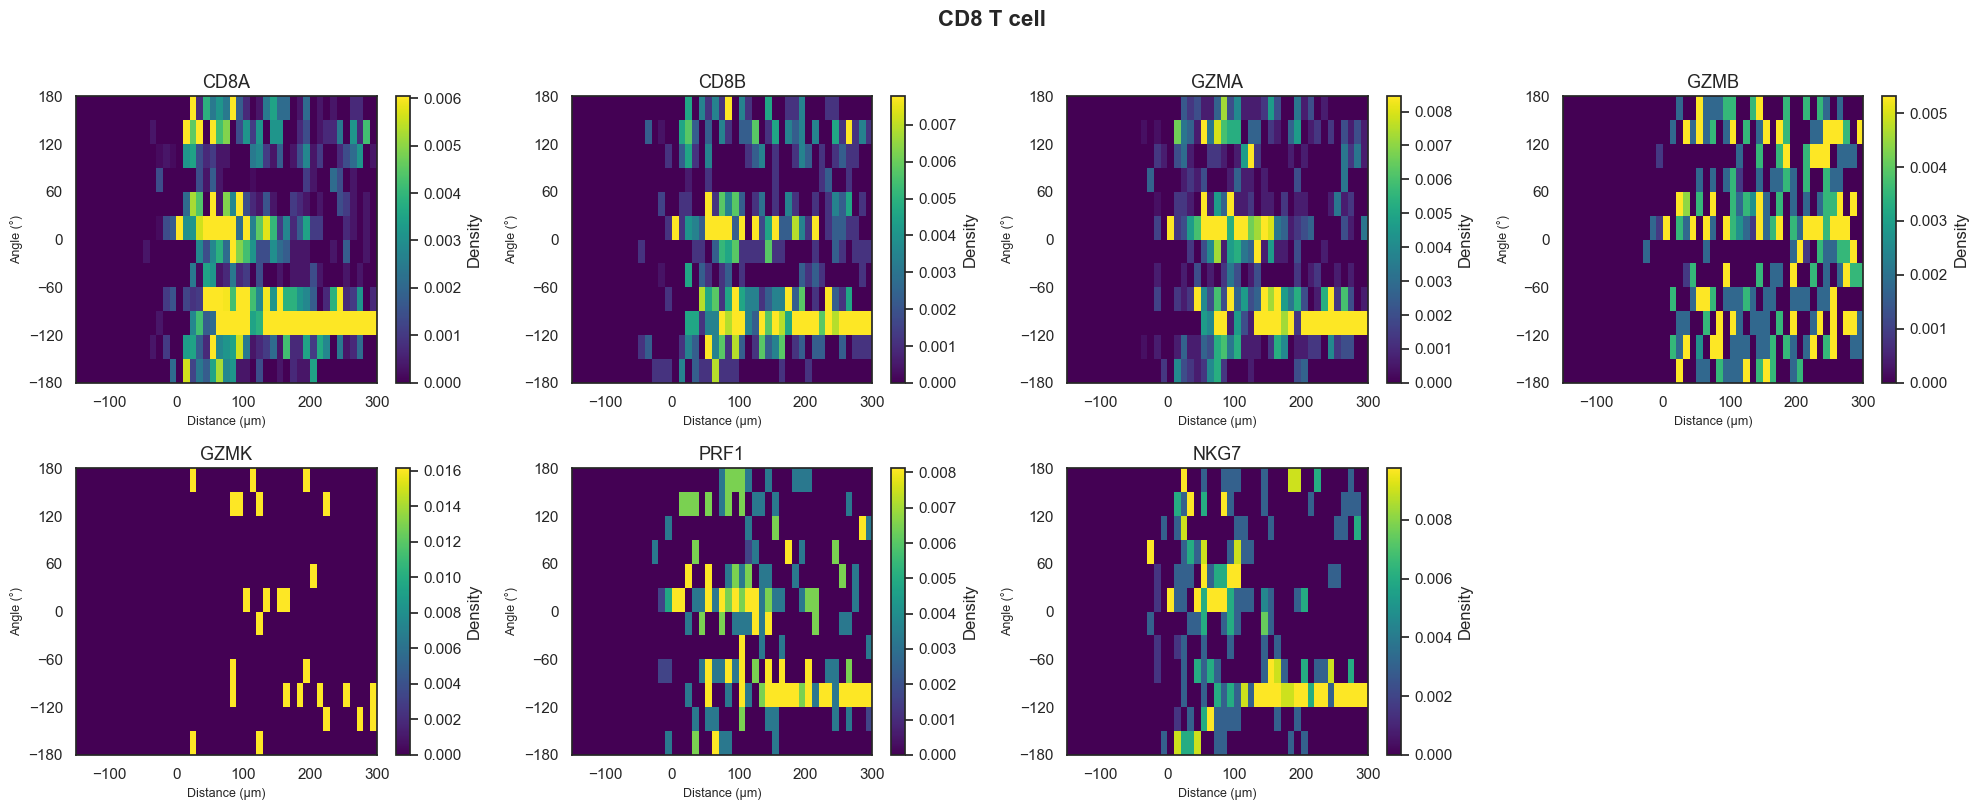

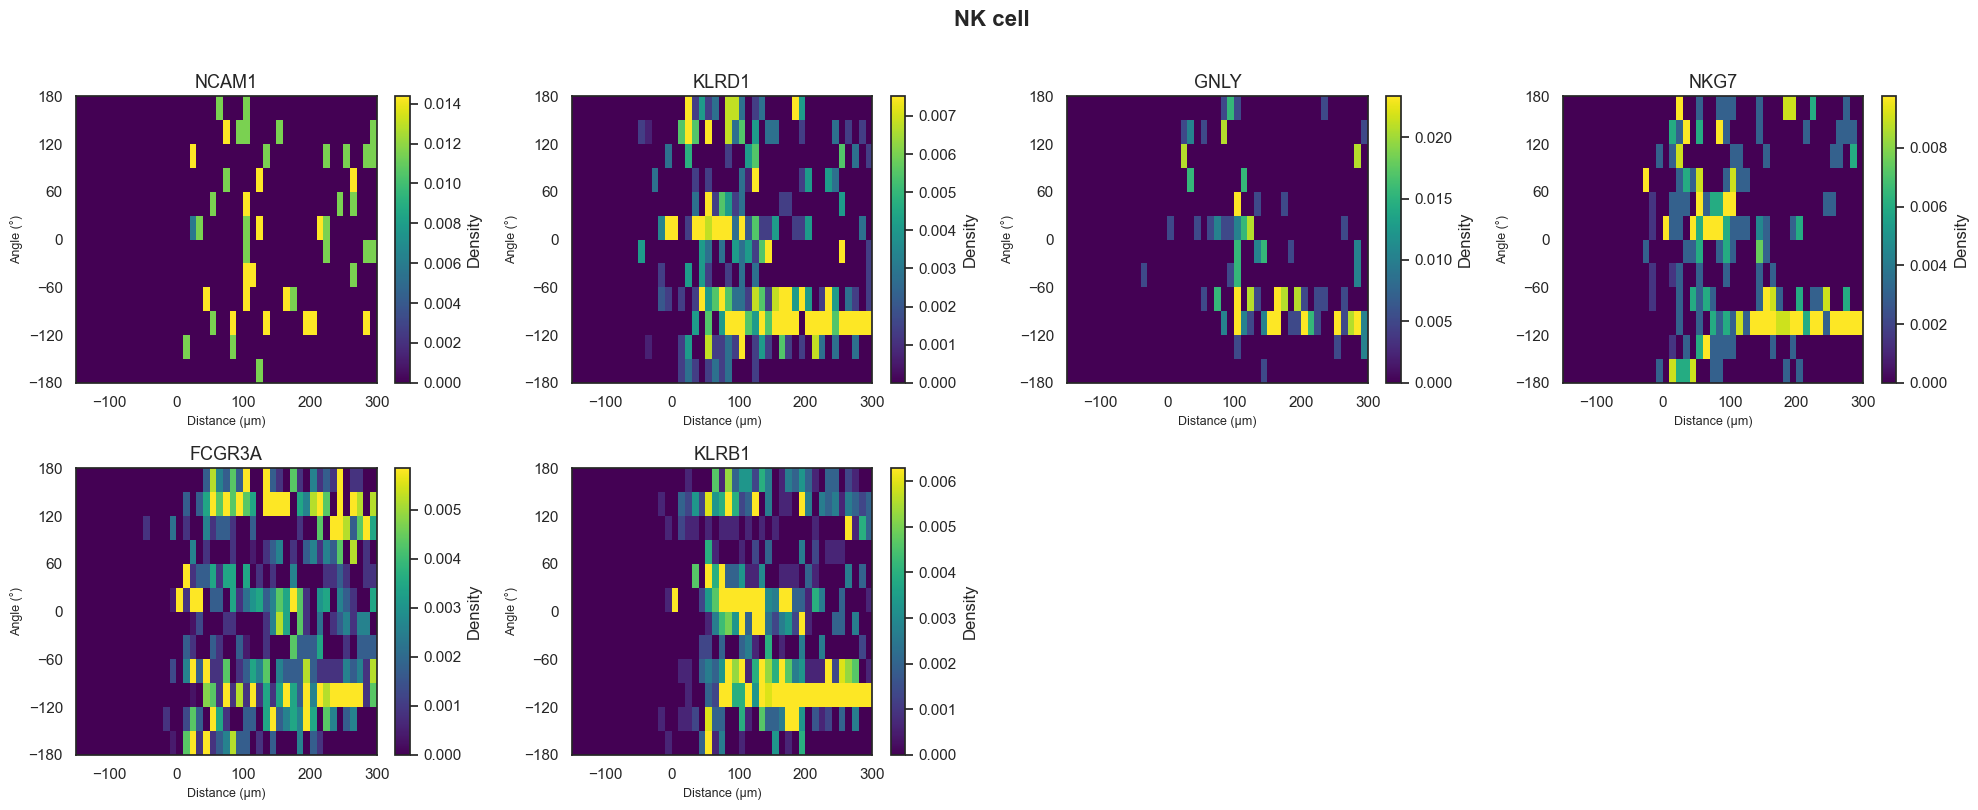

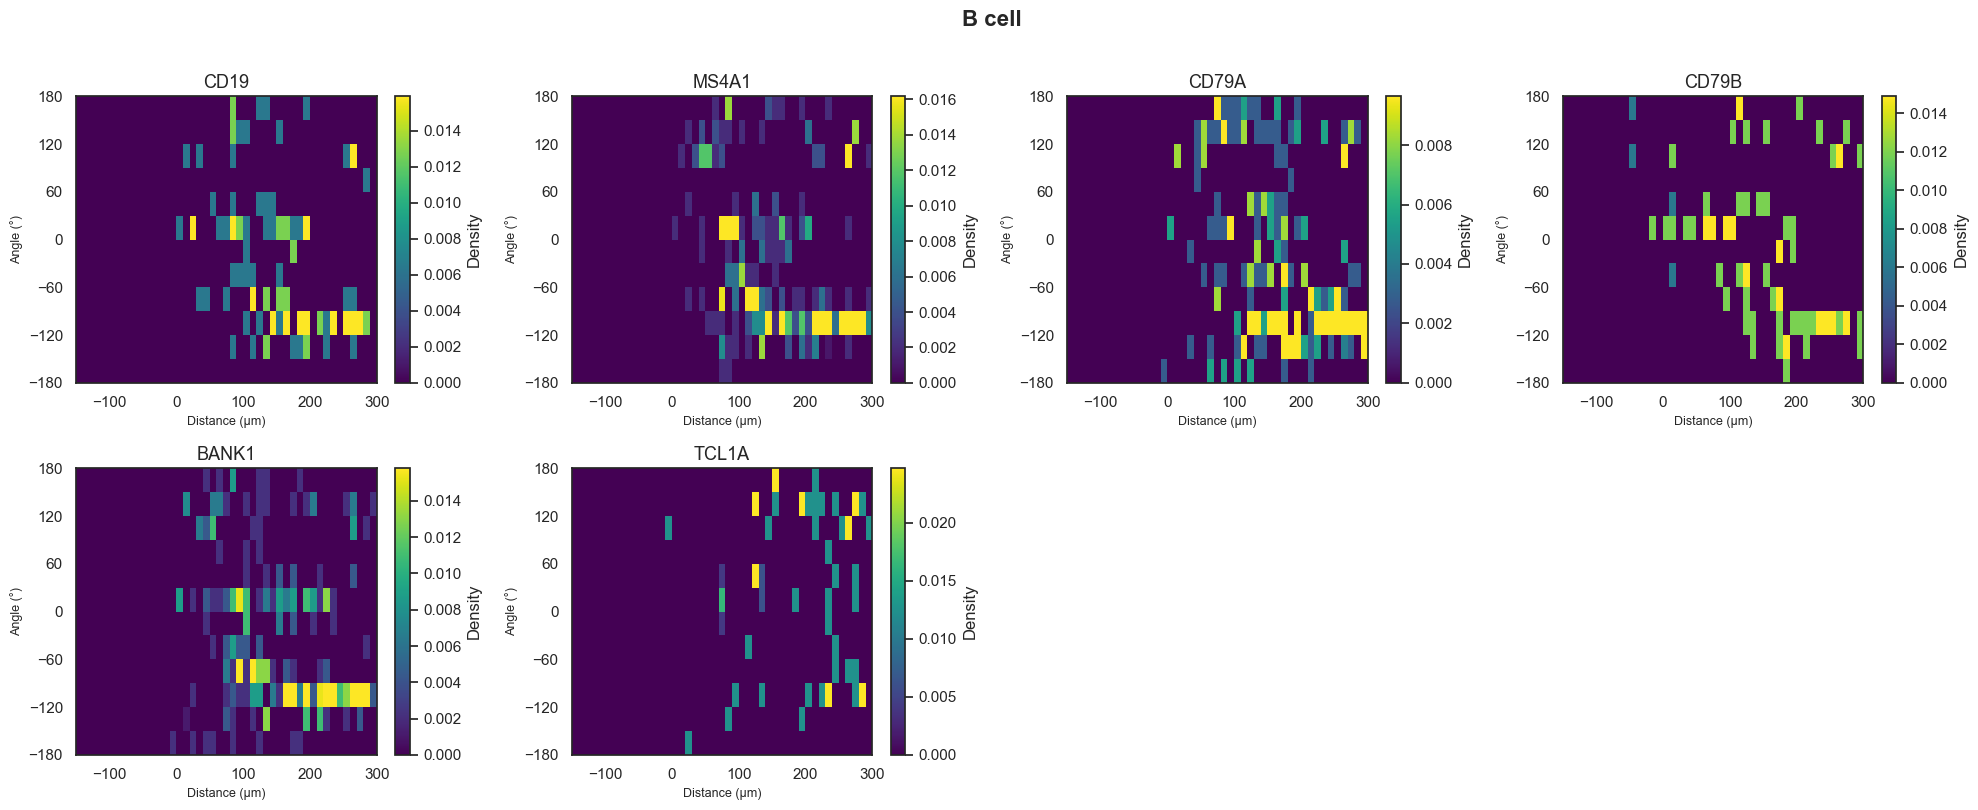

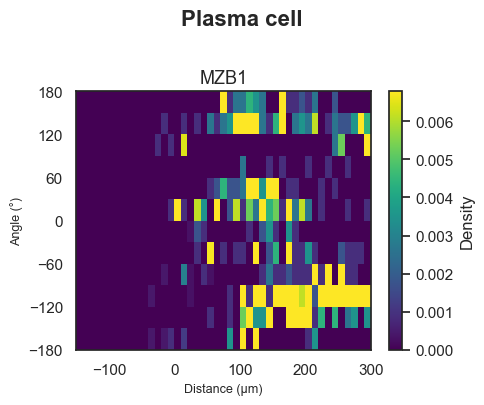

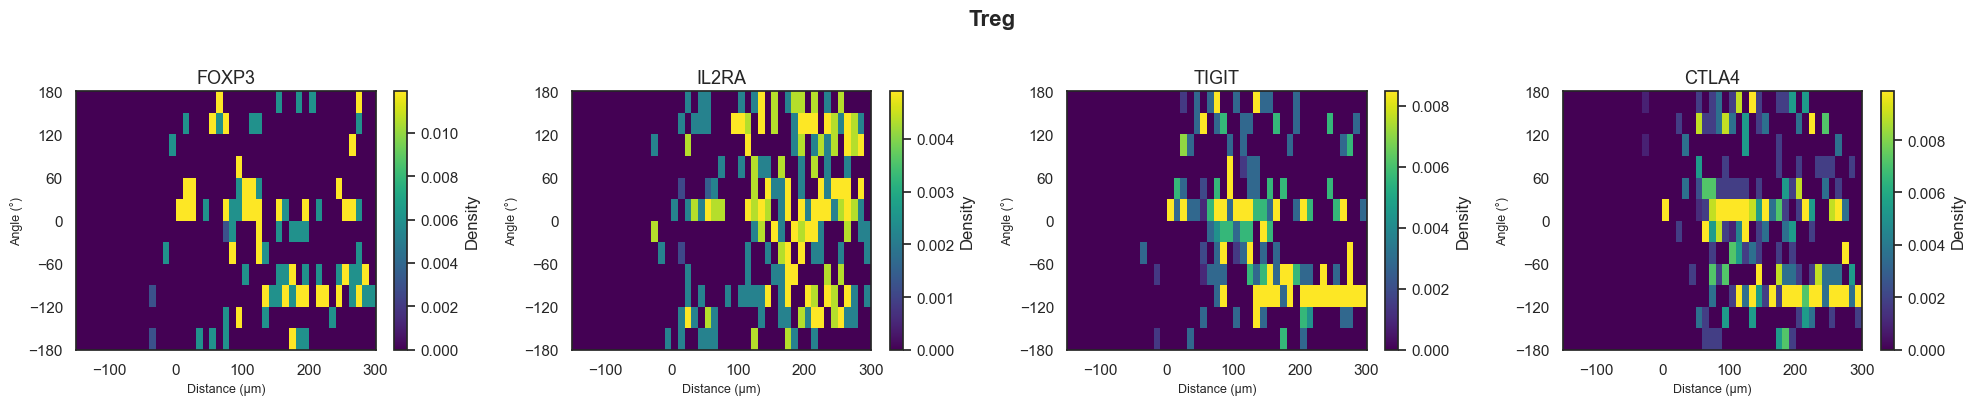

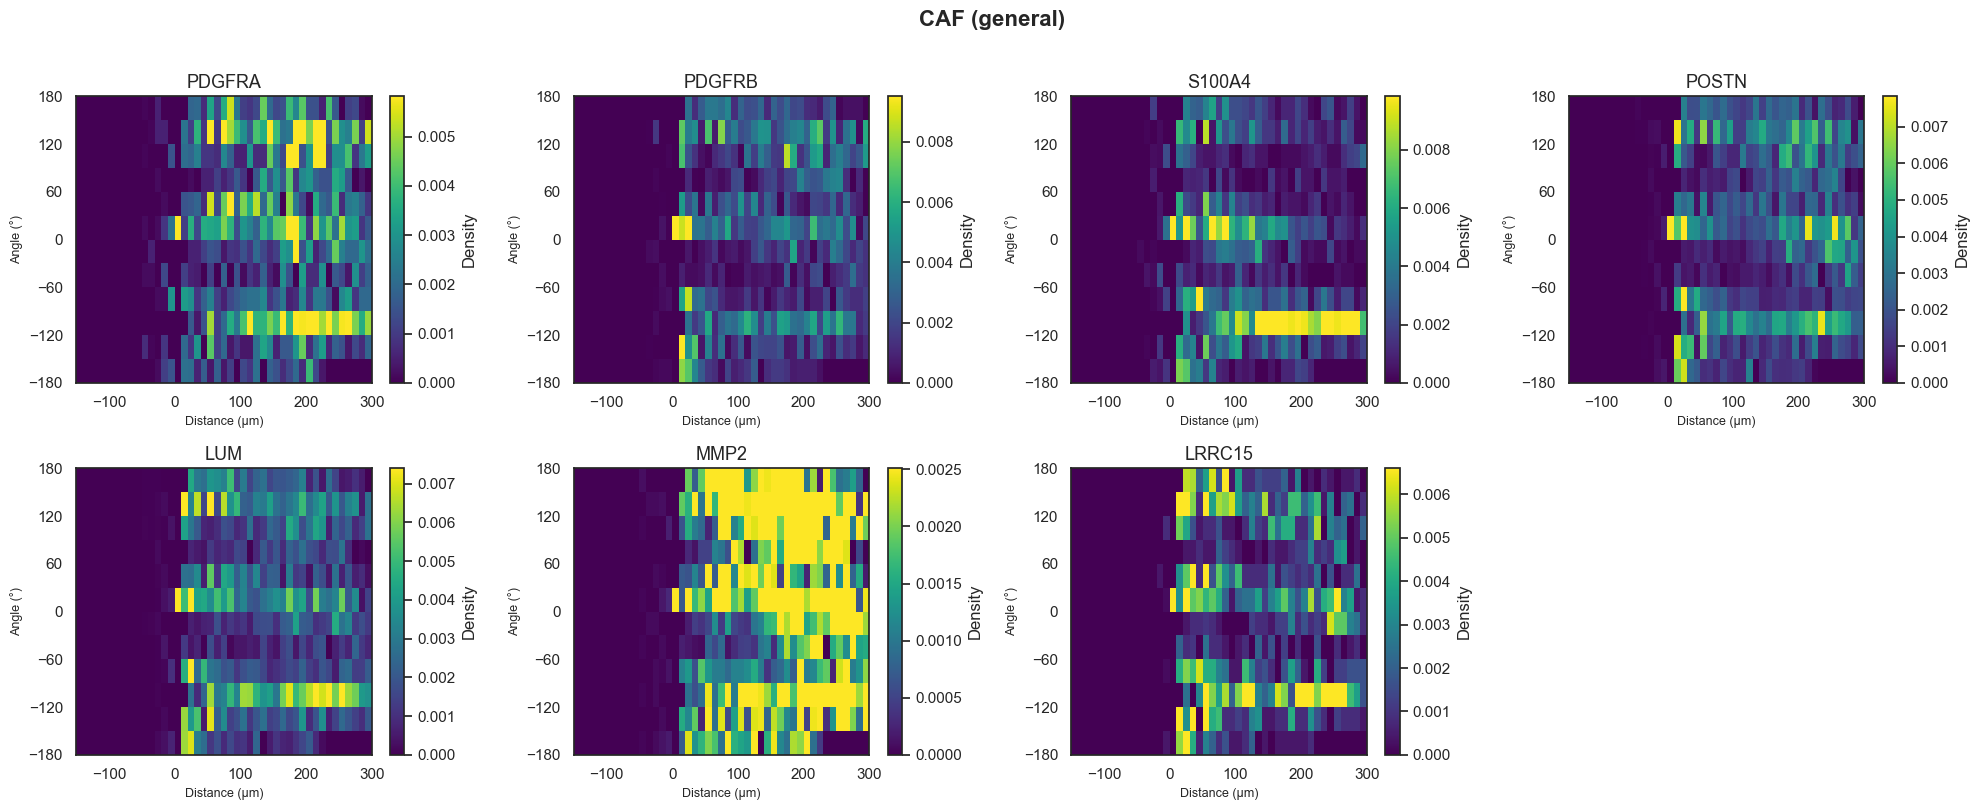

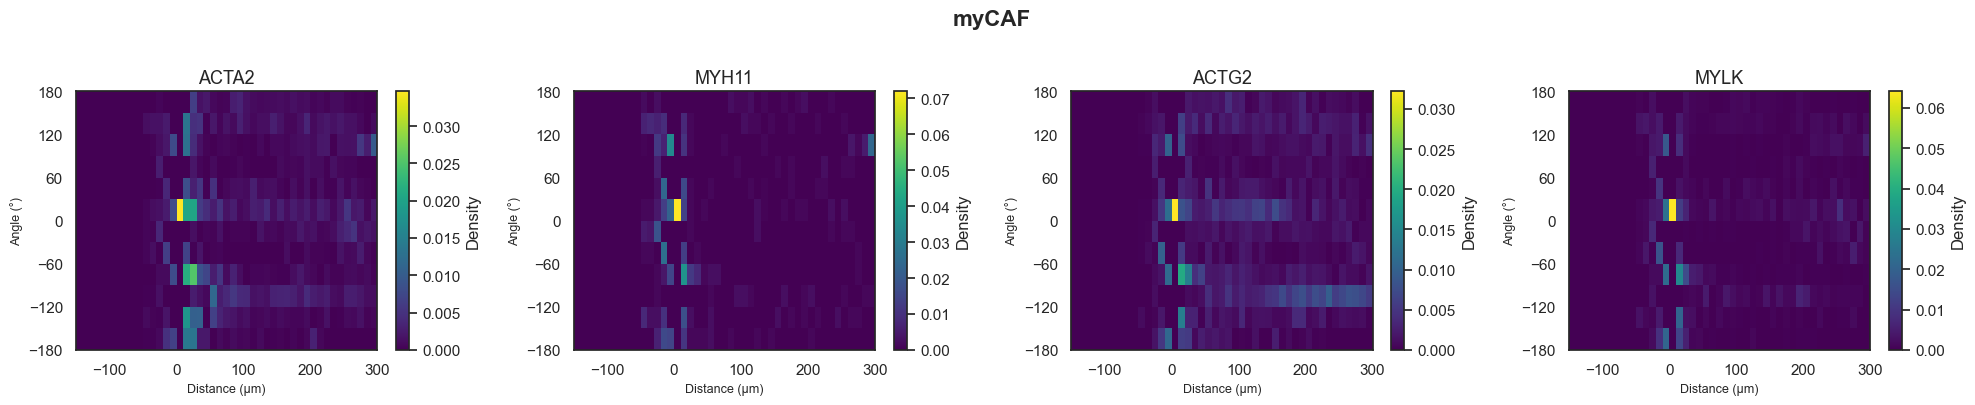

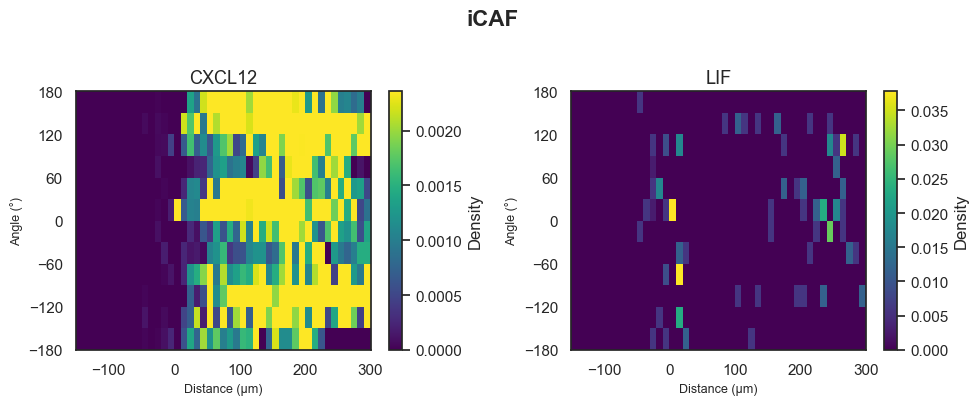

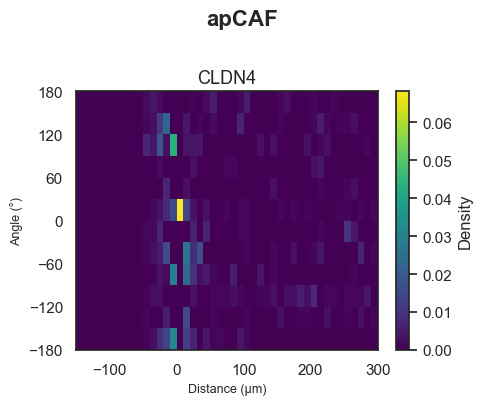

In [86]:
# ── Per-group polar heatmap grid ──────────────────────────────────────────
radius_bins   = np.arange(-150, 310, 10)
angle_bins_deg = np.arange(-180, 181, 30)
NCOLS = 4
CLIM_RATIO = 0.25

gene_to_counts = dict(zip(gene_pipe.selected_genes, gene_pipe.polar_counts_list))

for cell_type, genes in available_per_group.items():
    if not genes:
        print(f"[{cell_type}] No genes available – skipped.")
        continue

    n = len(genes)
    ncols = min(NCOLS, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    fig.suptitle(cell_type, fontsize=16, fontweight="bold", y=1.01)

    for idx, gene in enumerate(genes):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        A = gene_to_counts[gene]
        zmax = float(A.max()) * CLIM_RATIO if A.max() > 0 else 1.0

        im = ax.pcolormesh(radius_bins, angle_bins_deg, A.T,
                           cmap="viridis", vmin=0, vmax=zmax, shading="auto")
        ax.set_title(gene, fontsize=13)
        ax.set_xlabel("Distance (μm)", fontsize=9)
        ax.set_ylabel("Angle (°)", fontsize=9)
        ax.set_xlim(-150, 300)
        ax.set_yticks(np.arange(-180, 181, 60))
        plt.colorbar(im, ax=ax, label="Density")

    # Hide unused subplots
    for idx in range(n, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    plt.tight_layout()
    plt.show()

In [87]:
# ── T cell (general) ──────────────────────────────────────────────────────
_group = "T cell (general)"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ T cell (general) | CD3D


▶ T cell (general) | CD3E


▶ T cell (general) | CD3G


▶ T cell (general) | CD247


▶ T cell (general) | IL7R


▶ T cell (general) | SELL


▶ T cell (general) | PTPRC


In [88]:
# ── CD4 T cell ────────────────────────────────────────────────────────────
_group = "CD4 T cell"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ CD4 T cell | CD4


▶ CD4 T cell | IL2RA


▶ CD4 T cell | FOXP3


▶ CD4 T cell | CTLA4


▶ CD4 T cell | TIGIT


In [89]:
# ── CD8 T cell ────────────────────────────────────────────────────────────
_group = "CD8 T cell"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ CD8 T cell | CD8A


▶ CD8 T cell | CD8B


▶ CD8 T cell | GZMA


▶ CD8 T cell | GZMB


▶ CD8 T cell | GZMK


▶ CD8 T cell | PRF1


▶ CD8 T cell | NKG7


In [90]:
# ── NK cell ───────────────────────────────────────────────────────────────
_group = "NK cell"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ NK cell | NCAM1


▶ NK cell | KLRD1


▶ NK cell | GNLY


▶ NK cell | NKG7


▶ NK cell | FCGR3A


▶ NK cell | KLRB1


In [91]:
# ── B cell ────────────────────────────────────────────────────────────────
_group = "B cell"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ B cell | CD19


▶ B cell | MS4A1


▶ B cell | CD79A


▶ B cell | CD79B


▶ B cell | BANK1


▶ B cell | TCL1A


In [92]:
# ── Plasma cell ───────────────────────────────────────────────────────────
_group = "Plasma cell"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ Plasma cell | MZB1


In [93]:
# ── Treg ──────────────────────────────────────────────────────────────────
_group = "Treg"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ Treg | FOXP3


▶ Treg | IL2RA


▶ Treg | TIGIT


▶ Treg | CTLA4


In [94]:
# ── CAF (general) ─────────────────────────────────────────────────────────
_group = "CAF (general)"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ CAF (general) | PDGFRA


▶ CAF (general) | PDGFRB


▶ CAF (general) | S100A4


▶ CAF (general) | POSTN


▶ CAF (general) | LUM


▶ CAF (general) | MMP2


▶ CAF (general) | LRRC15


In [95]:
# ── myCAF ─────────────────────────────────────────────────────────────────
_group = "myCAF"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ myCAF | ACTA2


▶ myCAF | MYH11


▶ myCAF | ACTG2


▶ myCAF | MYLK


In [96]:
# ── iCAF ──────────────────────────────────────────────────────────────────
_group = "iCAF"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ iCAF | CXCL12


▶ iCAF | LIF


In [97]:
# ── apCAF ─────────────────────────────────────────────────────────────────
_group = "apCAF"
for _gene in available_per_group.get(_group, []):
    print(f"▶ {_group} | {_gene}")
    plot_polar_slice_interactive(
        A_counts=gene_to_counts[_gene],
        gene_name=_gene,
        subset_grid=gene_pipe.subset_grid,
        min_vector_df=gene_pipe.min_vector_df,
        bin_size=10,
    )

▶ apCAF | CLDN4


## Gene group metrics (uniformity / rho1 / rho2) by distance bin

PCoA で定義した遺伝子グループごとに、10-20 / 20-30 / 30-40 / 40-50 μm の各距離ビンにおける  
angle distribution metrics (uniformity, rho1, rho2) のバイオリンプロット。

In [ ]:
import seaborn as sns
from scomv.peripheral_score import compute_peripheral_score

# ── PCoA groups (cell 7c4a0064 と同じ定義) ──────────────────────────────────
_GROUPS_DEF = [
    ("T cell",        {"CD3D", "CD3E", "CD4", "CD247", "CD8A", "GZMA", "TRAC"}),
    ("B cell",        {"CD19", "BANK1", "MS4A1", "TCL1A", "CD79A"}),
    ("Epithelial",    {"CDH1", "EPCAM", "KRT8"}),
    ("Macrophage",    {"CD68", "CD80", "CD86", "CD163"}),
    ("Monocyte",      {"CD14"}),
    ("Smooth muscle", {"ACTA2", "MYH11", "ACTG2"}),
    ("Endothelial",   {"CD93", "PECAM1", "VWF"}),
    ("Fibroblast",    {"POSTN", "LUM", "MMP2"}),
]
GENE_GROUP = {}
for _lbl, _gset in _GROUPS_DEF:
    for _g in _gset:
        GENE_GROUP[_g] = _lbl

GROUP_ORDER = [g for g, _ in _GROUPS_DEF] + ["Other"]
GROUP_PALETTE = {
    "T cell":        "#1f77b4",
    "B cell":        "#17becf",
    "Epithelial":    "#ffbb78",
    "Macrophage":    "#2ca02c",
    "Monocyte":      "#ff9896",
    "Smooth muscle": "#aec7e8",
    "Endothelial":   "#8B4513",
    "Fibroblast":    "#d62728",
    "Other":         "#cccccc",
}

# ── 距離ビンごとにメトリクスを計算 ───────────────────────────────────────────
DIST_BINS = [("10-20 μm", 10, 20), ("20-30 μm", 20, 30),
             ("30-40 μm", 30, 40), ("40-50 μm", 40, 50)]

records = []
for gene, A in zip(gene_pipe.selected_genes, gene_pipe.polar_counts_list):
    grp = GENE_GROUP.get(gene, "Other")
    for bin_name, d_lo, d_hi in DIST_BINS:
        res = compute_peripheral_score(A, d_lo=d_lo, d_hi=d_hi)
        records.append({"gene": gene, "group": grp, "dist_bin": bin_name,
                         "uniformity": res["uniformity"],
                         "rho1": res["rho1"], "rho2": res["rho2"]})

df_gm = pd.DataFrame(records)
active_order = [g for g in GROUP_ORDER if g in df_gm["group"].unique()]

# ── バイオリンプロット ────────────────────────────────────────────────────────
for metric in ["uniformity", "rho1", "rho2"]:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5), dpi=100, sharey=True)
    for ax, (bin_name, d_lo, d_hi) in zip(axes, DIST_BINS):
        sub = df_gm[df_gm["dist_bin"] == bin_name]
        sns.violinplot(
            data=sub, x="group", y=metric,
            order=active_order, palette=GROUP_PALETTE,
            hue="group", legend=False,
            inner="box", linewidth=1.2, ax=ax,
        )
        sns.stripplot(
            data=sub, x="group", y=metric,
            order=active_order, palette=GROUP_PALETTE,
            hue="group", legend=False,
            size=3.5, jitter=True, alpha=0.55,
            linewidth=0.3, edgecolor="white", ax=ax,
        )
        ax.set_xlabel("")
        ax.set_xticklabels(
            [f"{g}
(n={len(sub[sub['group']==g])})" for g in active_order],
            rotation=40, ha="right", fontsize=8,
        )
        ax.set_title(bin_name, fontsize=10)
        ax.set_ylabel(metric if ax is axes[0] else "")
    fig.suptitle(f"{metric} — gene groups × distance bin",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
